# Notebook 07 — TuSimple Benchmark Evaluation

We now compute the **official TuSimple metric** — Accuracy, FPR, FNR — on
all 100 of our annotated frames. This is the headline number for the report.

For each frame:
1. Run the classical pipeline → get polynomial coefficients in BEV space
2. Sample the polynomials at the **same h_samples y-rows** as the ground truth
3. Transform those (x, y) pairs back to camera-view coordinates using `M_inv`
4. Compare to GT using the official metric

We will produce two numbers:
- Accuracy of the **single-frame** classical pipeline
- (Future) Accuracy of the smoothed pipeline (only meaningful on full clips,
  but the test set is mostly single annotated frames so we evaluate single-frame)

In [8]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from tusimple_loader import TuSimpleDataset
from perspective import PerspectiveWarper
from pipeline import ClassicalPipeline
from polyfit import evaluate_polynomial
from evaluate import (
    match_lanes_one_frame, evaluate_dataset, TuSimpleMetrics, PIXEL_THRESH
)

%matplotlib inline

dataset = TuSimpleDataset(
    annotation_file=project_root / "data/tusimple/test_subset/test_label_subset.json",
    image_root=project_root / "data/tusimple/test_subset",
)
warper = PerspectiveWarper()
pipeline = ClassicalPipeline(warper=warper)

available = dataset.existing_only()
print(f"Frames with images on disk: {len(available)}")

Frames with images on disk: 100


## 2. Evaluate single-frame pipeline on the 100-image test subset

For each frame:
1. Run the pipeline.
2. Convert the predicted polynomials back to **camera-view x positions**
   sampled at each y in the GT's h_samples.
3. Build the prediction list and call `match_lanes_one_frame`.

In [9]:
def predict_lanes_camera_view(image_rgb, pipeline, h_samples):
    """Run pipeline and return predicted lane x's at the given h_samples (camera view).
    
    Returns a list of x-arrays (one per predicted lane).
    """
    result = pipeline.detect(image_rgb)
    H_bev = result.bev.shape[0]
    
    # Generate dense (x, y) points along each polynomial in BEV space
    y_bev_dense = np.linspace(0, H_bev - 1, H_bev)
    
    pred_lanes = []
    for coeffs, detected in [(result.left_coeffs, result.left_detected),
                              (result.right_coeffs, result.right_detected)]:
        if not detected or coeffs is None:
            continue
        
        # Polynomial in BEV
        x_bev_dense = evaluate_polynomial(coeffs, y_bev_dense)
        bev_points = np.stack([x_bev_dense, y_bev_dense], axis=1)
        
        # Map back to camera view
        cam_points = pipeline.warper.unwarp_points(bev_points)
        
        # For each h_sample y, find the closest cam_point and grab its x.
        # cam_points isn't sorted by y because the homography distorts it,
        # so we interpolate.
        cam_x = cam_points[:, 0]
        cam_y = cam_points[:, 1]
        
        # Sort by y so we can use np.interp
        order = np.argsort(cam_y)
        cam_y_sorted = cam_y[order]
        cam_x_sorted = cam_x[order]
        
        # Sample at each h_sample y
        pred_x_at_h = np.interp(h_samples, cam_y_sorted, cam_x_sorted,
                                  left=-2, right=-2)
        # If a predicted polynomial doesn't extend to a y, np.interp clamps
        # but we set those to -2 (TuSimple's "not visible" marker)
        # Note: np.interp can't return -2 for outside-range; we set them manually
        
        # Mark out-of-range y's as -2 (mirror what GT does)
        outside_mask = (h_samples < cam_y_sorted.min()) | (h_samples > cam_y_sorted.max())
        pred_x_at_h[outside_mask] = -2
        
        pred_lanes.append(pred_x_at_h)
    
    return pred_lanes


# Evaluate on all available frames
print(f"Evaluating on {len(available)} frames...")
print(f"(uses pixel_thresh={PIXEL_THRESH}, pt_thresh=0.85)")
print()

frame_results = []
example_predictions = []  # for visualization later

for idx, sample in enumerate(tqdm(available)):
    image_rgb = cv2.cvtColor(cv2.imread(str(sample.image_path)), cv2.COLOR_BGR2RGB)
    
    h_samples = np.array(sample.h_samples, dtype=np.float32)
    gt_lanes = [np.array(lane, dtype=np.float32) for lane in sample.lanes]
    
    pred_lanes = predict_lanes_camera_view(image_rgb, pipeline, h_samples)
    
    # Match
    fr = match_lanes_one_frame(pred_lanes, gt_lanes)
    frame_results.append(fr)
    
    # Save first 4 examples for visualization
    if idx < 4:
        example_predictions.append({
            "sample": sample,
            "image": image_rgb,
            "h_samples": h_samples,
            "gt_lanes": gt_lanes,
            "pred_lanes": pred_lanes,
            "frame_result": fr,
        })

# Aggregate
metrics = evaluate_dataset(frame_results)
print()
print(metrics)

import json
metrics_json = {
    "accuracy": float(metrics.accuracy),
    "fpr": float(metrics.fpr),
    "fnr": float(metrics.fnr),
    "n_frames": metrics.n_frames,
    "total_pred_lanes": metrics.total_pred_lanes,
    "total_gt_lanes": metrics.total_gt_lanes,
    "pixel_thresh": 20,
    "pt_thresh": 0.85,
    "method": "classical pipeline (single-frame)",
}
with open(project_root / "results" / "tusimple_metrics_classical.json", "w") as f:
    json.dump(metrics_json, f, indent=2)
print(f"Saved metrics: results/tusimple_metrics_classical.json")

Evaluating on 100 frames...
(uses pixel_thresh=20, pt_thresh=0.85)



  0%|          | 0/100 [00:00<?, ?it/s]


TuSimple metrics over 100 frames:
  Accuracy:  99.08%
  FPR:       47.03%
  FNR:       73.37%
  Predicted lanes: 185
  GT lanes:        368
Saved metrics: results/tusimple_metrics_classical.json


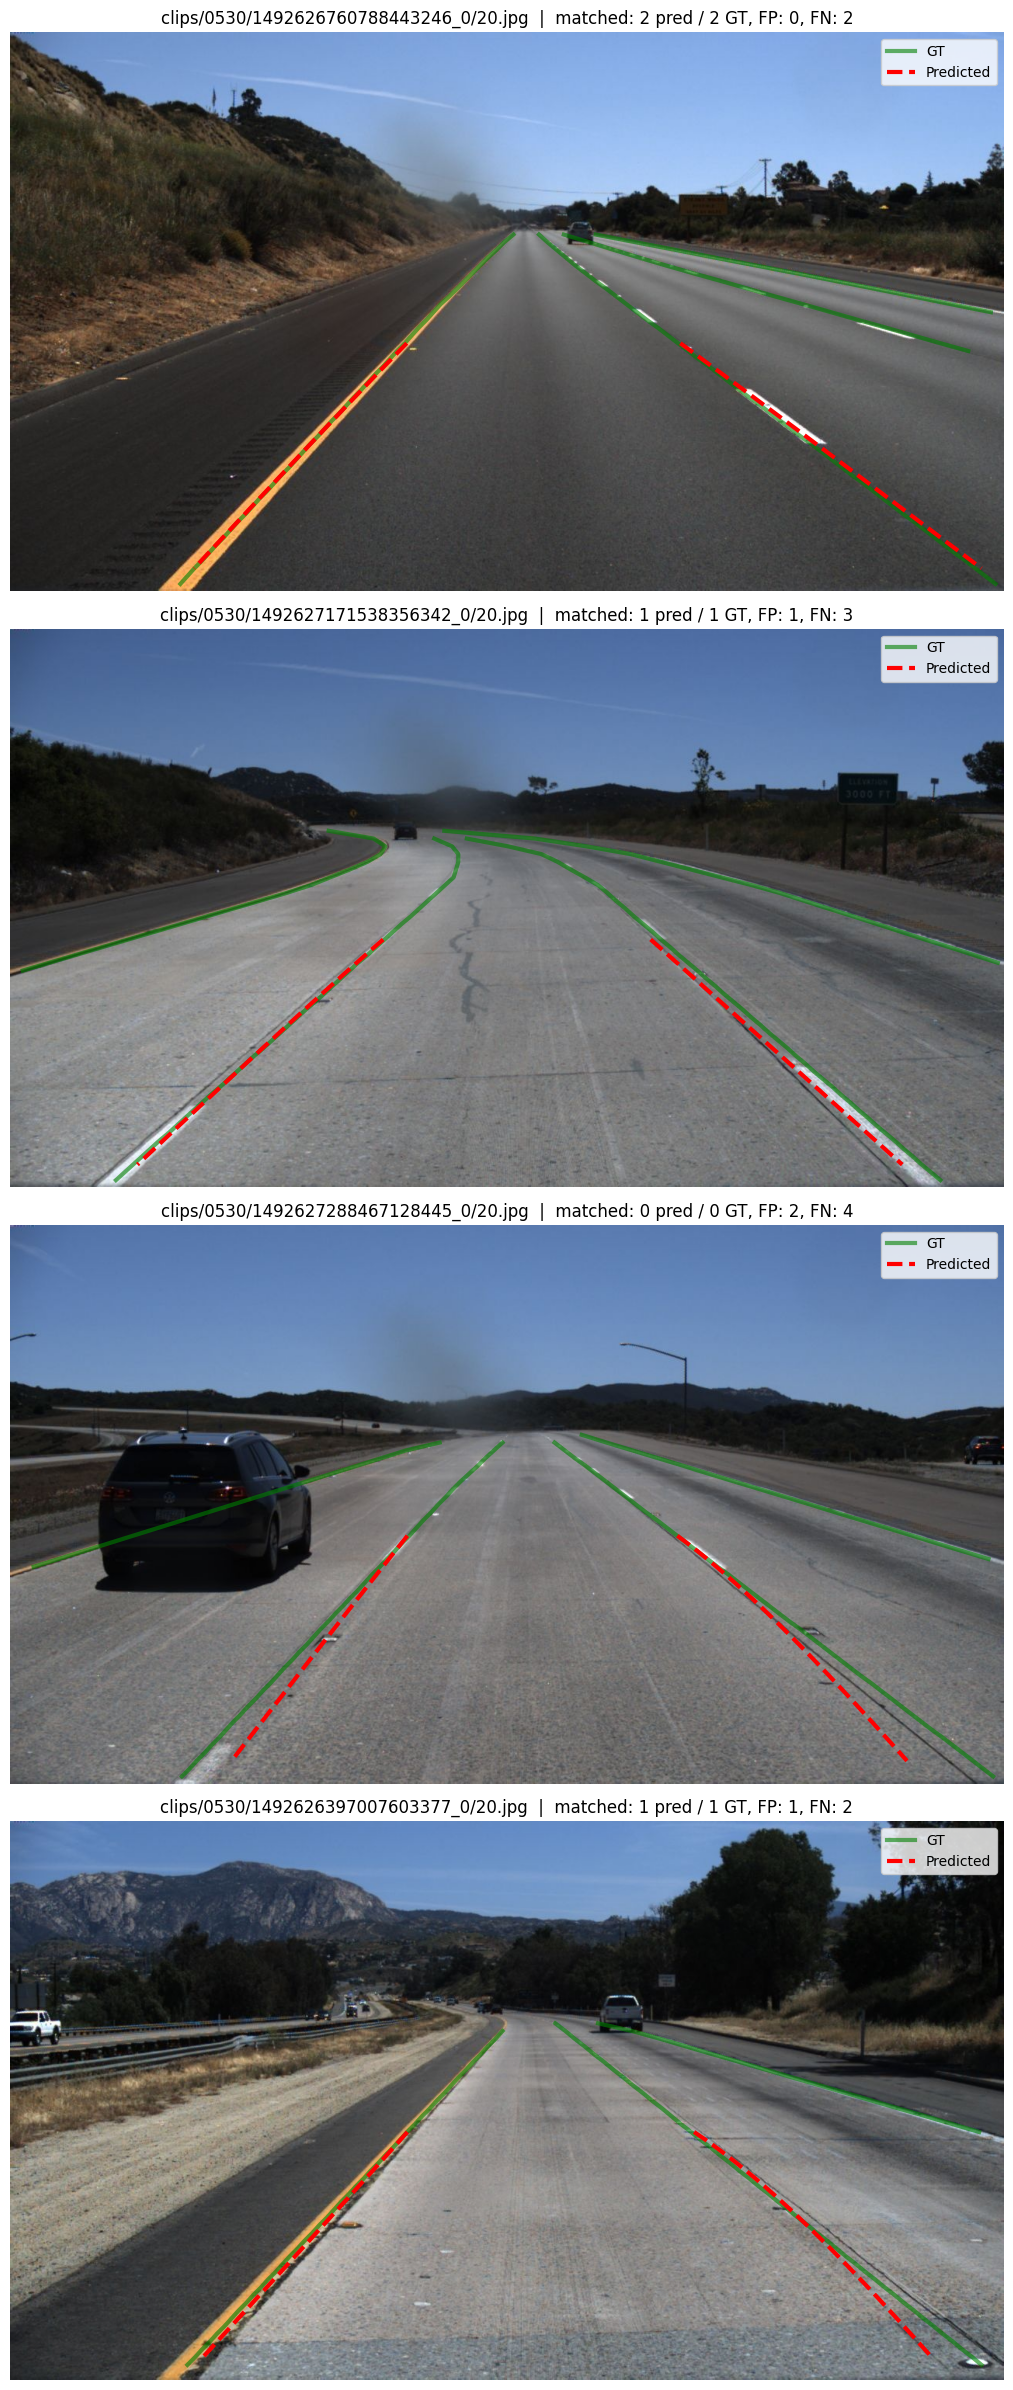

In [10]:
fig, axes = plt.subplots(len(example_predictions), 1, figsize=(14, 6 * len(example_predictions)))
if len(example_predictions) == 1:
    axes = [axes]

for ax, ex in zip(axes, example_predictions):
    ax.imshow(ex["image"])
    
    # Plot GT lanes
    for lane_idx, gt_lane in enumerate(ex["gt_lanes"]):
        valid = gt_lane != -2
        if valid.any():
            ax.plot(gt_lane[valid], ex["h_samples"][valid],
                    "g-", linewidth=3, alpha=0.6,
                    label="GT" if lane_idx == 0 else None)
    
    # Plot predicted lanes
    for lane_idx, pred_lane in enumerate(ex["pred_lanes"]):
        valid = pred_lane != -2
        if valid.any():
            ax.plot(pred_lane[valid], ex["h_samples"][valid],
                    "r--", linewidth=3,
                    label="Predicted" if lane_idx == 0 else None)
    
    fr = ex["frame_result"]
    ax.set_title(
        f"{ex['sample'].raw_file}  |  "
        f"matched: {fr['n_pred_matched']} pred / {fr['n_gt_matched']} GT, "
        f"FP: {fr['n_pred_unmatched']}, FN: {fr['n_gt_unmatched']}"
    )
    ax.legend(loc="upper right")
    ax.axis("off")

plt.tight_layout()
plt.savefig(project_root / "results" / "evaluation_examples.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
# === Diagnostic: print one frame's prediction vs GT row-by-row ===
ex = example_predictions[0]
sample = ex["sample"]
h_samples = ex["h_samples"]

print(f"Frame: {sample.raw_file}\n")
print(f"GT has {len(ex['gt_lanes'])} lanes, prediction has {len(ex['pred_lanes'])} lanes\n")

# Print prediction details
for pi, pred in enumerate(ex["pred_lanes"]):
    n_valid = (pred != -2).sum()
    print(f"PRED Lane {pi}: {n_valid}/{len(pred)} valid, "
          f"x range = [{pred[pred != -2].min():.1f}, {pred[pred != -2].max():.1f}]"
          if n_valid > 0 else f"PRED Lane {pi}: ALL -2 (empty!)")

print()

# Print GT details
for gi, gt in enumerate(ex["gt_lanes"]):
    n_valid = (gt != -2).sum()
    print(f"GT Lane {gi}: {n_valid}/{len(gt)} valid, "
          f"x range = [{gt[gt != -2].min():.1f}, {gt[gt != -2].max():.1f}]"
          if n_valid > 0 else f"GT Lane {gi}: ALL -2 (empty)")

# For each (pred, gt) pair, show how many y-rows BOTH have valid x
print()
print("Overlap analysis (rows where both pred and GT are valid):")
for pi, pred in enumerate(ex["pred_lanes"]):
    for gi, gt in enumerate(ex["gt_lanes"]):
        both_valid = (pred != -2) & (gt != -2)
        n_both = both_valid.sum()
        if n_both > 0:
            diffs = np.abs(pred[both_valid] - gt[both_valid])
            n_within_thresh = (diffs <= 20).sum()
            print(f"  PRED {pi} vs GT {gi}: {n_both} overlapping rows, "
                  f"{n_within_thresh} within 20px (mean diff = {diffs.mean():.1f})")
        else:
            print(f"  PRED {pi} vs GT {gi}: 0 overlapping rows!")

Frame: clips/0530/1492626760788443246_0/20.jpg

GT has 4 lanes, prediction has 2 lanes

PRED Lane 0: 30/56 valid, x range = [236.8, 510.6]
PRED Lane 1: 30/56 valid, x range = [863.0, 1250.9]

GT Lane 0: 46/56 valid, x range = [219.0, 648.0]
GT Lane 1: 46/56 valid, x range = [681.0, 1269.0]
GT Lane 2: 16/56 valid, x range = [713.0, 1234.0]
GT Lane 3: 11/56 valid, x range = [754.0, 1263.0]

Overlap analysis (rows where both pred and GT are valid):
  PRED 0 vs GT 0: 30 overlapping rows, 30 within 20px (mean diff = 0.8)
  PRED 0 vs GT 1: 30 overlapping rows, 0 within 20px (mean diff = 678.7)
  PRED 0 vs GT 2: 2 overlapping rows, 0 within 20px (mean diff = 710.3)
  PRED 0 vs GT 3: 0 overlapping rows!
  PRED 1 vs GT 0: 30 overlapping rows, 0 within 20px (mean diff = 685.4)
  PRED 1 vs GT 1: 30 overlapping rows, 30 within 20px (mean diff = 6.5)
  PRED 1 vs GT 2: 2 overlapping rows, 0 within 20px (mean diff = 346.1)
  PRED 1 vs GT 3: 0 overlapping rows!
